#Requirement

In [9]:
import sklearn
import fastapi
import uvicorn
from google import genai
from fastapi import FastAPI, HTTPException
from pydantic import BaseModel
from typing import List, Optional
import google.generativeai as genai
import tensorboard
import matplotlib
from sklearn.feature_extraction.text import TfidfVectorizer
import tensorflow as tf
import numpy as np
import pandas as pd
import zipfile
import os
import time
import matplotlib.pyplot as plt
import joblib
from datetime import datetime
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from transformers import pipeline
from tensorflow.keras.models import load_model
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences
from sklearn.metrics import accuracy_score
import warnings
warnings.filterwarnings('ignore')

#Data_Loader

In [2]:
def load_all_stock_data(stock_zip_path, extract_to='data/stock_csvs'):
    with zipfile.ZipFile(zip_path, 'r') as z:
        z.extractall(extract_to)
    stock_dfs = {}
    for file in os.listdir(extract_to):
        if file.endswith('.csv'):
            stock_name = file.replace('.csv', '')
            df = pd.read_csv(os.path.join(extract_to, file), parse_dates=['date'])
            df = df.sort_values('date')
            stock_dfs[stock_name] = df
    return stock_dfs

def load_all_sentiment_data(sentiment_zip_path, extract_to='data/sentiment_csvs'):
    with zipfile.ZipFile(zip_path, 'r') as z:
        z.extractall(extract_to)
    sent_dfs = {}
    for file in os.listdir(extract_to):
        if file.endswith('.csv'):
            stock_name = file.replace('.csv', '')
            df = pd.read_csv(os.path.join(extract_to, file), parse_dates=['date'])
            sent_dfs[stock_name] = df
    return sent_dfs

#Features

In [3]:
def create_time_series_features(df, target_col='close', window=20):
    df['return'] = df[target_col].pct_change()
    df = df.dropna().reset_index(drop=True)
    feature_cols = ['open', 'high', 'low', 'close', 'volume', 'return']
    data = df[feature_cols].values

    X, y = [], []
    for i in range(len(data) - window):
        X.append(data[i:i+window])
        y.append(data[i+window, -1])
    return np.array(X), np.array(y)

def create_sentiment_features(sent_df, date_range):
    daily_texts = sent_df.groupby('date')['text'].apply(lambda x: ' '.join(x)).reset_index()
    daily_texts = daily_texts[daily_texts['date'].isin(date_range)]
    daily_texts = daily_texts.sort_values('date')
    vectorizer = TfidfVectorizer(max_features=128, stop_words='english')
    tfidf_matrix = vectorizer.fit_transform(daily_texts['text'])
    return tfidf_matrix.toarray(), daily_texts['date'].values

#Train

In [4]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [6]:
stock_zip_path = '/content/drive/MyDrive/Colab Notebooks/Fintech_V2/Data_Saham.zip'
sentiment_zip_path = '/content/drive/MyDrive/Colab Notebooks/Fintech_V2/Sentimen_Saham.zip'
stock_dfs = {}
with zipfile.ZipFile(stock_zip_path, 'r') as z:
    for file in z.namelist():
        if file.endswith('.csv'):
            df = pd.read_csv(z.open(file), parse_dates=['date'])
            df['date'] = pd.to_datetime(df['date']).dt.normalize()
            stock_name = file.replace('.csv', '')
            stock_dfs[stock_name] = df.sort_values('date').reset_index(drop=True)
sentiment_dfs = {}
with zipfile.ZipFile(sentiment_zip_path, 'r') as z:
    for file in z.namelist():
        if file.endswith('.csv') and 'summary' not in file:
            df = pd.read_csv(z.open(file))
            if 'timestamp' in df.columns and 'text' in df.columns:
                df['date'] = pd.to_datetime(df['timestamp'], format='%a %b %d %H:%M:%S +0000 %Y', errors='coerce')
                df['date'] = df['date'].dt.normalize()
                df = df.dropna(subset=['date']).copy()
                df = df[['date', 'text']]
                if '_saham_' in file:
                    stock_name = file.split('_saham_')[0]
                else:
                    stock_name = file.replace('.csv', '')
                sentiment_dfs[stock_name] = df
            else:
                print(f"Skip {file}: tidak ada kolom timestamp/text")
best_stock = None
best_overlap = 0
for stock in stock_dfs:
    if stock not in sentiment_dfs:
        continue
    merged_test = pd.merge(stock_dfs[stock], sentiment_dfs[stock], on='date', how='inner')
    overlap_count = len(merged_test)
    if overlap_count > best_overlap:
        best_overlap = overlap_count
        best_stock = stock
if best_stock is None:
    raise ValueError("Tidak ada saham dengan overlap tanggal antara data saham dan sentimen.")
print(f"Menggunakan saham: {best_stock} dengan overlap {best_overlap} hari")
df_stock = stock_dfs[best_stock]
df_sent = sentiment_dfs[best_stock]
print("Loading sentiment model...")
sentiment_pipeline = pipeline("sentiment-analysis",
                              model="w11wo/indonesian-roberta-base-sentiment-classifier",
                              tokenizer="w11wo/indonesian-roberta-base-sentiment-classifier",
                              device=-1)
def get_sentiment_score(text):
    if not isinstance(text, str) or len(text.strip()) < 5:
        return 0.0
    try:
        result = sentiment_pipeline(text[:1000])[0]
        label = result['label'].lower()
        if label == 'positive':
            return 1.0
        elif label == 'negative':
            return -1.0
        else:
            return 0.0
    except:
        return 0.0
print("Menghitung skor sentimen per tweet...")
df_sent['sentiment_score'] = df_sent['text'].apply(get_sentiment_score)
daily_sentiment = df_sent.groupby('date')['sentiment_score'].mean().reset_index()
daily_sentiment.columns = ['date', 'sentiment_avg']
min_date = daily_sentiment['date'].min()
max_date = daily_sentiment['date'].max()
df_stock_filtered = df_stock[(df_stock['date'] >= min_date) & (df_stock['date'] <= max_date)].copy()
df_merged = pd.merge(df_stock_filtered, daily_sentiment, on='date', how='left')
df_merged['sentiment_avg'] = df_merged['sentiment_avg'].fillna(0)
feature_cols = ['open', 'high', 'low', 'close', 'volume', 'return',
                'volatility', 'ma20', 'rsi', 'macd', 'macd_signal', 'macd_diff']
df_merged['target'] = df_merged['return'].shift(-1)
df_merged = df_merged.dropna(subset=['target']).reset_index(drop=True)
window_size = 10
if len(df_merged) <= window_size:
    raise ValueError(f"Data terlalu sedikit ({len(df_merged)} baris) untuk window_size={window_size}")

X_ts = []
X_sent = []
y = []
for i in range(len(df_merged) - window_size):
    window_data = df_merged[feature_cols].iloc[i:i+window_size].values
    X_ts.append(window_data)
    sent_day = df_merged['sentiment_avg'].iloc[i+window_size-1]
    X_sent.append(sent_day)
    y.append(df_merged['target'].iloc[i+window_size-1])

X_ts = np.array(X_ts, dtype=np.float32)
X_sent = np.array(X_sent, dtype=np.float32).reshape(-1, 1)
y = np.array(y, dtype=np.float32)

print(f"Shape X_ts: {X_ts.shape}, X_sent: {X_sent.shape}, y: {y.shape}")

if X_ts.shape[0] == 0:
    raise ValueError("Tidak ada sampel yang dihasilkan. Periksa window_size atau overlap data.")
scaler_ts = StandardScaler()
original_shape = X_ts.shape
X_ts_flat = X_ts.reshape(original_shape[0], -1)
X_ts_norm = scaler_ts.fit_transform(X_ts_flat).reshape(original_shape)

scaler_sent = StandardScaler()
X_sent_norm = scaler_sent.fit_transform(X_sent)

X_ts_train, X_ts_val, X_sent_train, X_sent_val, y_train, y_val = train_test_split(
    X_ts_norm, X_sent_norm, y, test_size=0.2, random_state=42, shuffle=True
)
def quantile_huber_loss(y_true, y_pred, delta=1.0, tau=0.5):
    residual = y_true - y_pred
    huber = tf.where(tf.abs(residual) <= delta,
                     0.5 * tf.square(residual),
                     delta * (tf.abs(residual) - 0.5 * delta))
    return tf.reduce_mean(tf.where(residual >= 0, tau * huber, (1 - tau) * huber))

class MAECheckpoint(tf.keras.callbacks.Callback):
    def __init__(self, min_mae=0.02, filepath='/content/drive/MyDrive/Colab Notebooks/Fintech_V2/finsight_model.keras'):
        super().__init__()
        self.min_mae = min_mae
        self.filepath = filepath
        self.best_mae = np.inf

    def on_epoch_end(self, epoch, logs=None):
        current_mae = logs.get('val_mae')
        if current_mae and current_mae < self.best_mae and current_mae <= self.min_mae:
            self.best_mae = current_mae
            self.model.save(self.filepath)
            print(f"\nModel saved with val_mae = {current_mae:.5f}")
ts_input = tf.keras.Input(shape=(window_size, len(feature_cols)), name='time_series')
x = tf.keras.layers.LSTM(64, return_sequences=True)(ts_input)
x = tf.keras.layers.LSTM(32)(x)
x = tf.keras.layers.Dropout(0.3)(x)

sent_input = tf.keras.Input(shape=(1,), name='sentiment')
s = tf.keras.layers.Dense(16, activation='relu')(sent_input)
s = tf.keras.layers.Dense(8, activation='relu')(s)

concat = tf.keras.layers.Concatenate()([x, s])
z = tf.keras.layers.Dense(32, activation='relu')(concat)
z = tf.keras.layers.Dropout(0.2)(z)
output = tf.keras.layers.Dense(1, activation='linear', name='prediction')(z)

model = tf.keras.Model(inputs=[ts_input, sent_input], outputs=output)
model.compile(optimizer=tf.keras.optimizers.Adam(1e-3),
              loss=quantile_huber_loss,
              metrics=['mae'])
model.summary()
log_dir = "logs/tensorboard/" + datetime.now().strftime("%Y%m%d-%H%M%S")
tensorboard_cb = tf.keras.callbacks.TensorBoard(log_dir=log_dir)
checkpoint_cb = MAECheckpoint(min_mae=0.02, filepath='/content/drive/MyDrive/Colab Notebooks/Fintech_V2/finsight_model.keras')
early_stop = tf.keras.callbacks.EarlyStopping(monitor='val_mae', patience=10, mode='min', restore_best_weights=True)
train_log_dir = 'logs/gradient_tape/' + datetime.now().strftime("%Y%m%d-%H%M%S")
train_summary_writer = tf.summary.create_file_writer(train_log_dir)
optimizer = tf.keras.optimizers.Adam(learning_rate=1e-3)
loss_fn = quantile_huber_loss
batch_size = 32
train_dataset = tf.data.Dataset.from_tensor_slices(((X_ts_train, X_sent_train), y_train))
train_dataset = train_dataset.shuffle(1024).batch(batch_size).prefetch(tf.data.AUTOTUNE)
val_dataset = tf.data.Dataset.from_tensor_slices(((X_ts_val, X_sent_val), y_val))
val_dataset = val_dataset.batch(batch_size).prefetch(tf.data.AUTOTUNE)
epochs = 100
best_mae = float('inf')
best_weights = None
for epoch in range(epochs):
    epoch_loss_avg = tf.keras.metrics.Mean()
    epoch_mae_avg = tf.keras.metrics.Mean()

    for step, ((x_ts, x_sent), y_batch) in enumerate(train_dataset):
        with tf.GradientTape() as tape:
            predictions = model([x_ts, x_sent], training=True)
            loss = loss_fn(y_batch, predictions)

        grads = tape.gradient(loss, model.trainable_variables)
        optimizer.apply_gradients(zip(grads, model.trainable_variables))

        epoch_loss_avg.update_state(loss)
        mae = tf.reduce_mean(tf.abs(y_batch - predictions))
        epoch_mae_avg.update_state(mae)
    val_loss_avg = tf.keras.metrics.Mean()
    val_mae_avg = tf.keras.metrics.Mean()
    for (x_ts, x_sent), y_batch in val_dataset:
        val_pred = model([x_ts, x_sent], training=False)
        val_loss = loss_fn(y_batch, val_pred)
        val_loss_avg.update_state(val_loss)
        val_mae_avg.update_state(tf.reduce_mean(tf.abs(y_batch - val_pred)))
    with train_summary_writer.as_default():
        tf.summary.scalar('loss/train', epoch_loss_avg.result(), step=epoch)
        tf.summary.scalar('mae/train', epoch_mae_avg.result(), step=epoch)
        tf.summary.scalar('loss/val', val_loss_avg.result(), step=epoch)
        tf.summary.scalar('mae/val', val_mae_avg.result(), step=epoch)

    print(f"Epoch {epoch+1:3d} | Loss: {epoch_loss_avg.result():.5f} | MAE: {epoch_mae_avg.result():.5f} | Val Loss: {val_loss_avg.result():.5f} | Val MAE: {val_mae_avg.result():.5f}")
    if val_mae_avg.result().numpy() < best_mae and val_mae_avg.result().numpy() <= 0.02:
        best_mae = val_mae_avg.result().numpy()
        best_weights = model.get_weights()
        model.save('/content/drive/MyDrive/Colab Notebooks/Fintech_V2/finsight_model_custom.keras')
        print(f"Model saved with val_mae = {best_mae:.5f}")
model.set_weights(best_weights)
print(f"Best validation MAE: {best_mae:.5f}")
y_pred = model.predict([X_ts_val, X_sent_val])
mae = tf.reduce_mean(tf.abs(y_val - y_pred)).numpy()
print(f"Validation MAE: {mae:.5f}")
if mae <= 0.02:
    print("Sesuai syarat")
else:
    print("Melebihi")
import joblib
joblib.dump(scaler_ts, '/content/drive/MyDrive/Colab Notebooks/Fintech_V2/scaler_ts.pkl')
joblib.dump(scaler_sent, '/content/drive/MyDrive/Colab Notebooks/Fintech_V2/scaler_sent.pkl')

Menggunakan saham: BBRI dengan overlap 417 hari
Loading sentiment model...


Loading weights:   0%|          | 0/201 [00:00<?, ?it/s]

RobertaForSequenceClassification LOAD REPORT from: w11wo/indonesian-roberta-base-sentiment-classifier
Key                             | Status     |  | 
--------------------------------+------------+--+-
roberta.embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


Menghitung skor sentimen per tweet...
Shape X_ts: (10, 10, 12), X_sent: (10, 1), y: (10,)


Model: "functional_1"

...

 Total params: 33,641 (131.41 KB)

 Trainable params: 33,641 (131.41 KB)

 Non-trainable params: 0 (0.00 B)

Epoch   1 | Loss: 0.02097 | MAE: 0.25037 | Val Loss: 0.00772 | Val MAE: 0.17511
Epoch   2 | Loss: 0.01698 | MAE: 0.23020 | Val Loss: 0.00614 | Val MAE: 0.15668
Epoch   3 | Loss: 0.01129 | MAE: 0.17480 | Val Loss: 0.00454 | Val MAE: 0.13410
Epoch   4 | Loss: 0.00749 | MAE: 0.14778 | Val Loss: 0.00289 | Val MAE: 0.10662
Epoch   5 | Loss: 0.01217 | MAE: 0.15431 | Val Loss: 0.00141 | Val MAE: 0.07489
Epoch   6 | Loss: 0.00895 | MAE: 0.16872 | Val Loss: 0.00078 | Val MAE: 0.05531
Epoch   7 | Loss: 0.00614 | MAE: 0.12242 | Val Loss: 0.00058 | Val MAE: 0.04307
Epoch   8 | Loss: 0.00348 | MAE: 0.08503 | Val Loss: 0.00029 | Val MAE: 0.02512
Epoch   9 | Loss: 0.00277 | MAE: 0.07056 | Val Loss: 0.00020 | Val MAE: 0.02828
Epoch  10 | Loss: 0.00285 | MAE: 0.07800 | Val Loss: 0.00024 | Val MAE: 0.02432
Epoch  11 | Loss: 0.00159 | MAE: 0.06511 | Val Loss: 0.00039 | Val MAE: 0.03636
Epoch  12 | Loss: 0.00231 | MAE: 0.08654 | Val Loss: 0.00069 | Val MAE: 0.05254
Epoch  13 | Loss: 0.00211 | MAE: 0.06578

['/content/drive/MyDrive/Colab Notebooks/Fintech_V2/scaler_sent.pkl']

#Model_Sentimen

Total data sentimen: 175 positif/negatif


Model: "functional_5"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ text_input (InputLayer)         │ (None, 100)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ embedding_3 (Embedding)         │ (None, 100, 128)       │     1,280,000 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bidirectional_3 (Bidirectional) │ (None, 100, 128)       │        98,816 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_max_pooling1d_3          │ (None, 128)            │             0 │
│ (GlobalMaxPooling1D)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_9 (Dense)                 │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_7 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ sentiment_output (Dense)        │ (None, 1)              │            65 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,387,137 (5.29 MB)

 Trainable params: 1,387,137 (5.29 MB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/20
5/5 ━━━━━━━━━━━━━━━━━━━━ 9s 617ms/step - accuracy: 0.6357 - loss: 0.6803 - val_accuracy: 0.6571 - val_loss: 0.6611
Epoch 2/20
5/5 ━━━━━━━━━━━━━━━━━━━━ 1s 108ms/step - accuracy: 0.6429 - loss: 0.6570 - val_accuracy: 0.6571 - val_loss: 0.6365
Epoch 3/20
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 92ms/step - accuracy: 0.6429 - loss: 0.6204 - val_accuracy: 0.6571 - val_loss: 0.6189
Epoch 4/20
5/5 ━━━━━━━━━━━━━━━━━━━━ 1s 83ms/step - accuracy: 0.6429 - loss: 0.5953 - val_accuracy: 0.6571 - val_loss: 0.5917
Epoch 5/20
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 56ms/step - accuracy: 0.6786 - loss: 0.5507 - val_accuracy: 0.6571 - val_loss: 0.5433
Epoch 6/20
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 39ms/step - accuracy: 0.7286 - loss: 0.4507 - val_accuracy: 0.6571 - val_loss: 0.5572
Epoch 7/20
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 40ms/step - accuracy: 0.8643 - loss: 0.3304 - val_accuracy: 0.8286 - val_loss: 0.3280
Epoch 8/20
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 39ms/step - accuracy: 0.9500 - loss: 0.2283 - val_accuracy: 0.8286 - val_loss: 0.338

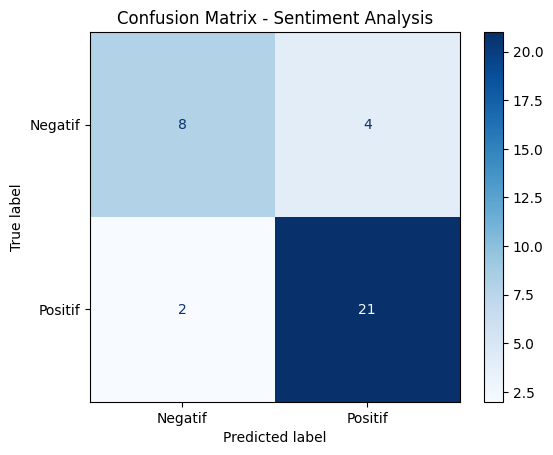

['/content/drive/MyDrive/Colab Notebooks/Fintech_V2/tokenizer_sent.pkl']

In [14]:
sentences = df_sent['text'].dropna().astype(str).values
labels = df_sent['sentiment_score'].values
mask = labels != 0.0
sentences = sentences[mask]
labels = labels[mask]
labels = np.where(labels == 1.0, 1, 0)
print(f"Total data sentimen: {len(sentences)} positif/negatif")
MAX_WORDS = 10000
MAX_LEN = 100
tokenizer_sent = Tokenizer(num_words=MAX_WORDS, oov_token='<OOV>')
tokenizer_sent.fit_on_texts(sentences)
sequences = tokenizer_sent.texts_to_sequences(sentences)
X_sentiment = pad_sequences(sequences, maxlen=MAX_LEN)
y_sentiment = labels
X_sent_train, X_sent_test, y_sent_train, y_sent_test = train_test_split(
    X_sentiment, y_sentiment, test_size=0.2, random_state=42, stratify=y_sentiment
)
input_text = tf.keras.Input(shape=(MAX_LEN,), name='text_input')
x = tf.keras.layers.Embedding(MAX_WORDS, 128, input_length=MAX_LEN)(input_text)
x = tf.keras.layers.Bidirectional(tf.keras.layers.LSTM(64, return_sequences=True))(x)
x = tf.keras.layers.GlobalMaxPooling1D()(x)
x = tf.keras.layers.Dense(64, activation='relu')(x)
x = tf.keras.layers.Dropout(0.5)(x)
output_sent = tf.keras.layers.Dense(1, activation='sigmoid', name='sentiment_output')(x)
sentiment_model = tf.keras.Model(inputs=input_text, outputs=output_sent)
sentiment_model.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])
sentiment_model.summary()
sentiment_log_dir = "logs/sentiment/" + datetime.now().strftime("%Y%m%d-%H%M%S")
sentiment_tensorboard = tf.keras.callbacks.TensorBoard(log_dir=sentiment_log_dir)
history_sent = sentiment_model.fit(
    X_sent_train, y_sent_train,
    validation_data=(X_sent_test, y_sent_test),
    epochs=20,
    batch_size=32,
    callbacks=[sentiment_tensorboard],
    verbose=1
)
y_pred_prob = sentiment_model.predict(X_sent_test)
y_pred = (y_pred_prob > 0.5).astype(int)
acc = accuracy_score(y_sent_test, y_pred)
print(f"Akurasi model sentimen: {acc:.4f}")
#assert acc >= 0.85, f"Akurasi {acc:.4f} < 85%, perlu tuning"
cm = confusion_matrix(y_sent_test, y_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['Negatif', 'Positif'])
disp.plot(cmap='Blues')
plt.title('Confusion Matrix - Sentiment Analysis')
plt.savefig('confusion_matrix_sentiment.png')
plt.show()
sentiment_model.save('/content/drive/MyDrive/Colab Notebooks/Fintech_V2/sentiment_model.keras')
joblib.dump(tokenizer_sent, '/content/drive/MyDrive/Colab Notebooks/Fintech_V2/tokenizer_sent.pkl')

#Inference

In [15]:
class FinSightInference:
    def __init__(self, stock_model_path, sentiment_model_path, scaler_ts_path, scaler_sent_path, tokenizer_path):
        self.stock_model = load_model(stock_model_path, custom_objects={'quantile_huber_loss': quantile_huber_loss})
        self.sentiment_model = load_model(sentiment_model_path)
        self.scaler_ts = joblib.load(scaler_ts_path)
        self.scaler_sent = joblib.load(scaler_sent_path)
        self.tokenizer = joblib.load(tokenizer_path)
        self.window_size = 10
        self.feature_cols = ['open', 'high', 'low', 'close', 'volume', 'return',
                             'volatility', 'ma20', 'rsi', 'macd', 'macd_signal', 'macd_diff']
    def predict_stock(self, recent_features, sentiment_score):
        recent_norm = self.scaler_ts.transform(recent_features.reshape(1, -1)).reshape(1, self.window_size, -1)
        sent_norm = self.scaler_sent.transform([[sentiment_score]])
        pred = self.stock_model.predict([recent_norm, sent_norm], verbose=0)
        return pred[0, 0]
    def predict_sentiment(self, text):
        seq = self.tokenizer.texts_to_sequences([text])
        padded = pad_sequences(seq, maxlen=100)
        prob = self.sentiment_model.predict(padded, verbose=0)[0, 0]
        return "POSITIF" if prob > 0.5 else "NEGATIF", prob
inference = FinSightInference(
    stock_model_path='/content/drive/MyDrive/Colab Notebooks/Fintech_V2/finsight_model_custom.keras',
    sentiment_model_path='/content/drive/MyDrive/Colab Notebooks/Fintech_V2/sentiment_model.keras',
    scaler_ts_path='/content/drive/MyDrive/Colab Notebooks/Fintech_V2/scaler_ts.pkl',
    scaler_sent_path='/content/drive/MyDrive/Colab Notebooks/Fintech_V2/scaler_sent.pkl',
    tokenizer_path='/content/drive/MyDrive/Colab Notebooks/Fintech_V2/tokenizer_sent.pkl'
)
sample_text = "Saham BBRI turun drastis karena kebijakan bank sentral"
sent_label, prob = inference.predict_sentiment(sample_text)
print(f"Sentimen: {sent_label} (prob={prob:.3f})")

Sentimen: NEGATIF (prob=0.016)


#Tokenizer

In [22]:
joblib.dump(tokenizer_sent, '/content/drive/MyDrive/Colab Notebooks/Fintech_V2/tokenizer_sent.pkl')
!zip -r tensorboard_logs.zip '/content/drive/MyDrive/Colab Notebooks/Fintech_V2/logs/'

  adding: content/drive/MyDrive/Colab Notebooks/Fintech_V2/logs/ (stored 0%)
